# Dissertation

# Processing data

### Cleaning the dataset and exporting it to "clean_week" CSV

In [61]:
import glob
import numpy as np
import pandas as pd

# load all raw CSVs
csv_files = glob.glob("data/*.csv")
print(f"found {len(csv_files)} CSV file/s")

df = pd.concat(
     [pd.read_csv(f) for f in csv_files],
     ignore_index=True
# )

print(f"raw shape: {df.shape}")

# clean whitespace from column names
df.columns = df.columns.str.strip()

# convert labels to 0/1
df["Label"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

print(f"class balance: benign; {(df.Label == 0).sum()}, attack; {(df.Label == 1).sum()}")

# replace inf with NaN, then drop NaN rows
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# remove zero-variance columns
feature_cols = df.columns.drop("Label")
zero_var_cols = feature_cols[df[feature_cols].nunique() <= 1]
df = df.drop(columns=zero_var_cols)

# remove highly correlated features
corr = df.drop("Label", axis=1).corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.85)]

df = df.drop(columns=to_drop)

# remove duplicate rows
df = df.drop_duplicates()

print(
    f"after cleaning: {df.shape}, "
    f"dropped {len(zero_var_cols)} zero-var, "
    f"{len(to_drop)} correlated cols"
# )

# save cleaned dataset
df.to_csv("week_cleaned.csv", index=False)

print("Saved to week_cleaned.csv")

### Importing from Cleaned data + Splitting

In [62]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# load cleaned dataset
df = pd.read_csv("week_cleaned.csv")

print(f"loaded cleaned data: {df.shape}")

# prep features and labels
X = df.drop("Label", axis=1)
y = df["Label"]

feature_names = list(X.columns)

# creating the train/test split @ 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

# scale features
scaler = StandardScaler()

X_train_s = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names,
    index=X_train.index
)

X_test_s = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)

# verification
print("\n── Verification ──")
print("NaNs remaining  :", df.isna().sum().sum())
print("Infs remaining  :", np.isinf(df.select_dtypes(include=[np.number])).sum().sum())
print("Duplicates left :", df.duplicated().sum())
print("Train mean (scaled, first 3 cols):", X_train_s.iloc[:, :3].mean().values.round(4))
print("Train std  (scaled, first 3 cols):", X_train_s.iloc[:, :3].std().values.round(4))
print("preprocessing finished")

loaded cleaned data: (1930056, 37)
Train: (1544044, 36)  Test: (386012, 36)

── Verification ──
NaNs remaining  : 0
Infs remaining  : 0
Duplicates left : 0
Train mean (scaled, first 3 cols): [-0.  0.  0.]
Train std  (scaled, first 3 cols): [1. 1. 1.]
preprocessing finished


# Implementing AI models

##### XGBoost

In [63]:
from xgboost import XGBClassifier

# calculate class imbalance ratio
neg, pos = np.bincount(y_train)
scale_pos = neg / pos
print(f"Class weight ratio: {scale_pos:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)
xgb.fit(X_train_s, y_train)
print("XGBoost training complete")

Class weight ratio: 7.32
XGBoost training complete


##### SVM

In [64]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

MAX_TRAIN = 50000
#MAX_TRAIN = 50000 #for testing

if len(X_train_s) > MAX_TRAIN:
    print(f"subsampling {len(X_train_s):,} rows into {MAX_TRAIN:,}")
    idx = np.random.RandomState(42).choice(len(X_train_s), MAX_TRAIN, replace=False)
    X_svm = X_train_s.iloc[idx]
    y_svm = y_train.iloc[idx]
else:
    X_svm, y_svm = X_train_s, y_train

base_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

svm = CalibratedClassifierCV(base_svm, cv=3)

print("training Linear SVM")
svm.fit(X_svm, y_svm)
print("Linear SVM training complete")

subsampling 1,544,044 rows into 50,000
training Linear SVM
Linear SVM training complete


##### DNN

In [ ]:
from sklearn.neural_network import MLPClassifier

DNN_TRAIN_SAMPLE_SIZE = 50000 
# DNN_TRAIN_SAMPLE_SIZE = 50000 

# hidden_layer_sizes=(256, 128, 64, 32)  vs  (64, 32) #for testing
# max_iter=100 vs 20

X_train_dnn_test = X_train_s.iloc[:DNN_TRAIN_SAMPLE_SIZE]
y_train_dnn_test = y_train.iloc[:DNN_TRAIN_SAMPLE_SIZE]

dnn = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=512,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=3,
    random_state=42,
    verbose=False
)


print("Training DNN...")
dnn.fit(X_train_dnn_test, y_train_dnn_test)
print("DNN training complete")

Training fast test DNN...
Fast test DNN training complete


## Verify AI models

#### Visual output


  XGBoost
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    339615
      Attack       0.99      1.00      0.99     46397

    accuracy                           1.00    386012
   macro avg       0.99      1.00      1.00    386012
weighted avg       1.00      1.00      1.00    386012


  SVM
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97    339615
      Attack       0.80      0.78      0.79     46397

    accuracy                           0.95    386012
   macro avg       0.89      0.88      0.88    386012
weighted avg       0.95      0.95      0.95    386012


  DNN
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99    339615
      Attack       0.91      0.95      0.93     46397

    accuracy                           0.98    386012
   macro avg       0.95      0.97      0.96    386012
weighted avg       0.98      0.98      0.98    38

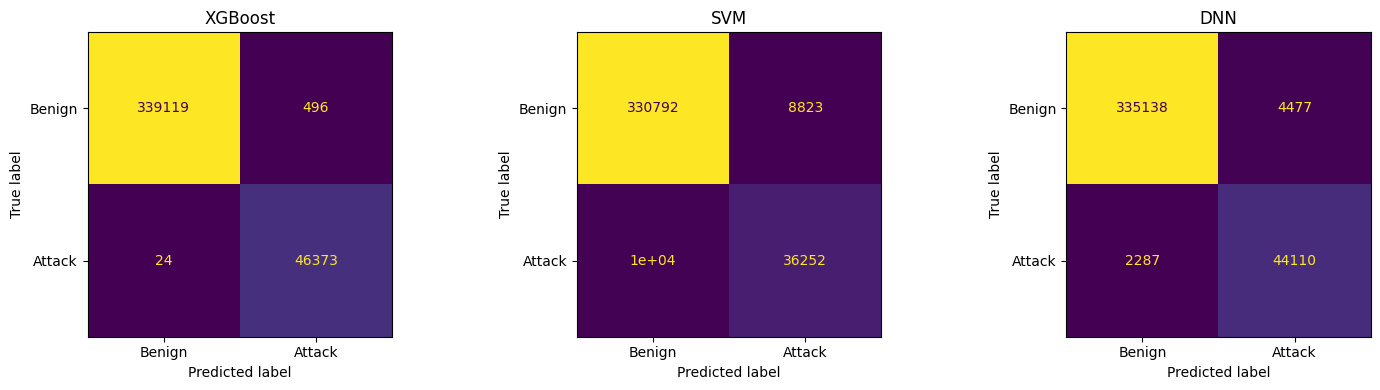

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, [("XGBoost", xgb), ("SVM", svm), ("DNN", dnn)]):
    y_pred = model.predict(X_test_s)

    print(f"\n{'='*40}\n  {name}\n{'='*40}")
    print(classification_report(y_test, y_pred, target_names=["Benign", "Attack"]))

    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                  display_labels=["Benign", "Attack"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout() 
plt.show()

#### Recorded metrics verification 

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# store trained models here later
models = {
    "SVM": svm,
    "XGBoost": xgb,
    "DNN": dnn
}

results = []

for name, model in models.items():
    print(f"\n===== {name} =====")

    # predict on unseen test data
    y_pred = model.predict(X_test_s)

    # if DNN gives probabilities instead of 0/1 labels, convert them
    if len(y_pred.shape) > 1:
        y_pred = (y_pred > 0.5).astype(int).ravel()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    print("Confusion matrix:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

model_results = pd.DataFrame(results)
model_results


===== SVM =====
Confusion matrix:
[[330792   8823]
 [ 10145  36252]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    339615
           1       0.80      0.78      0.79     46397

    accuracy                           0.95    386012
   macro avg       0.89      0.88      0.88    386012
weighted avg       0.95      0.95      0.95    386012


===== XGBoost =====
Confusion matrix:
[[339119    496]
 [    24  46373]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    339615
           1       0.99      1.00      0.99     46397

    accuracy                           1.00    386012
   macro avg       0.99      1.00      1.00    386012
weighted avg       1.00      1.00      1.00    386012


===== DNN =====
Confusion matrix:
[[335138   4477]
 [  2287  44110]]

Classification report:
              precision    recall  f1-score   support

     

,Model,Accuracy,Precision,Recall,F1
0,SVM,0.950862,0.804260,0.781344,0.792636
1,XGBoost,0.998653,0.989417,0.999483,0.994425
2,DNN,0.982477,0.907856,0.950708,0.928788


# Implementing the XAI

## SHAP


===== XGBoost SHAP bar chart =====


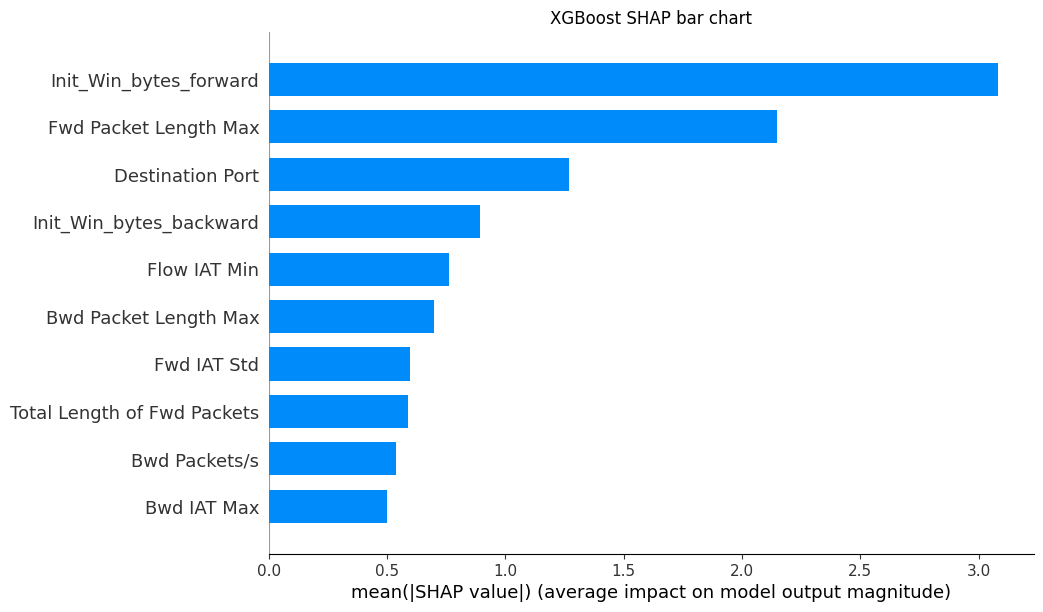


===== XGBoost SHAP beeswarm plot =====


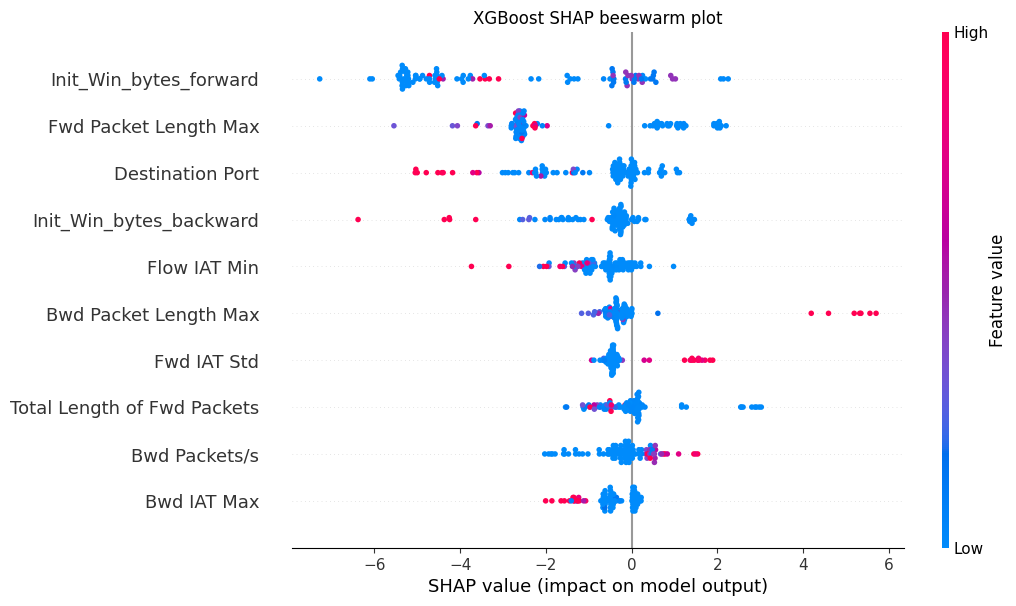


===== SVM SHAP bar chart =====


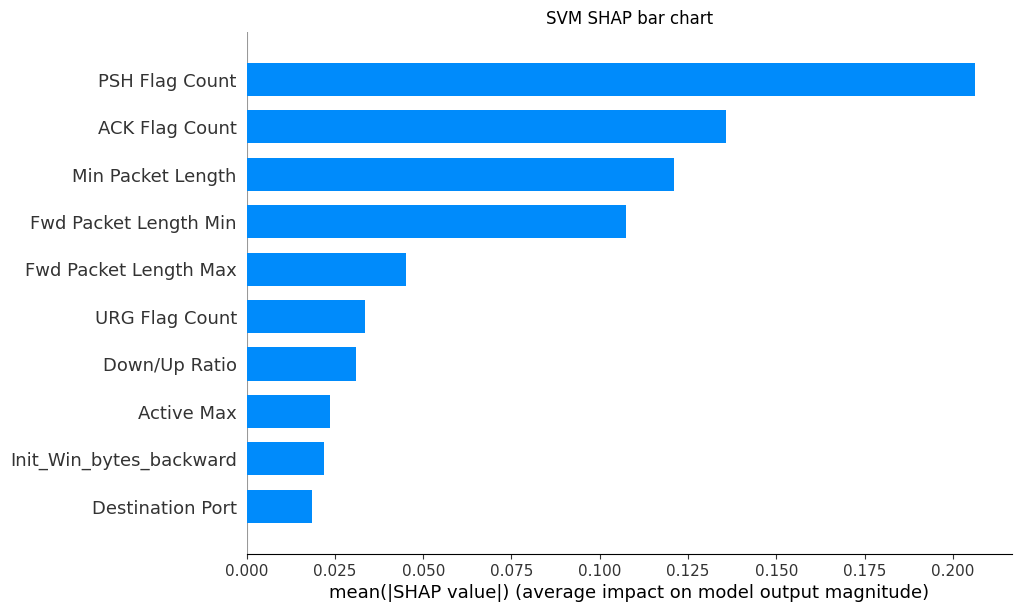


===== SVM SHAP beeswarm plot =====


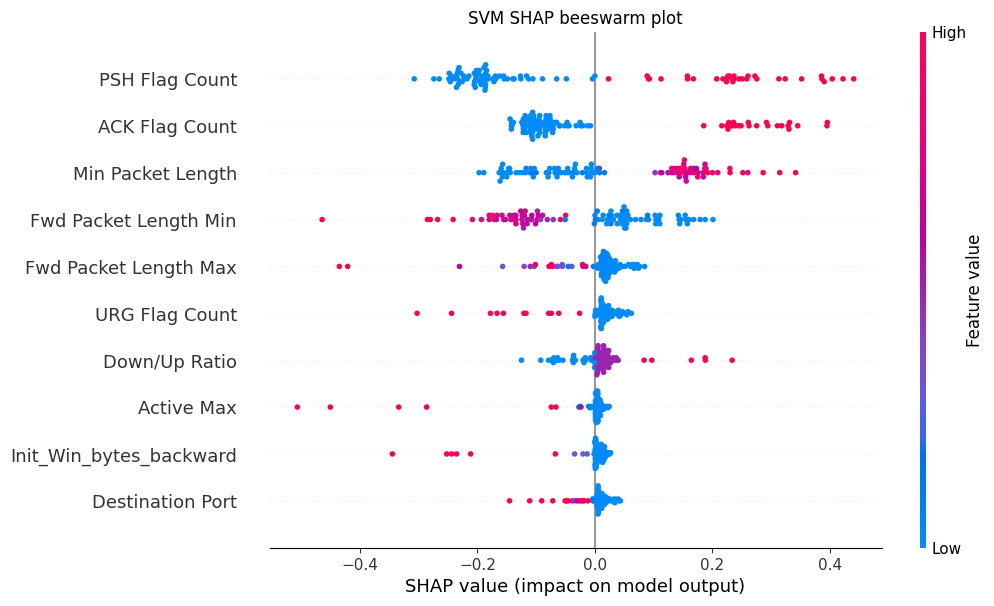


===== DNN SHAP bar chart =====


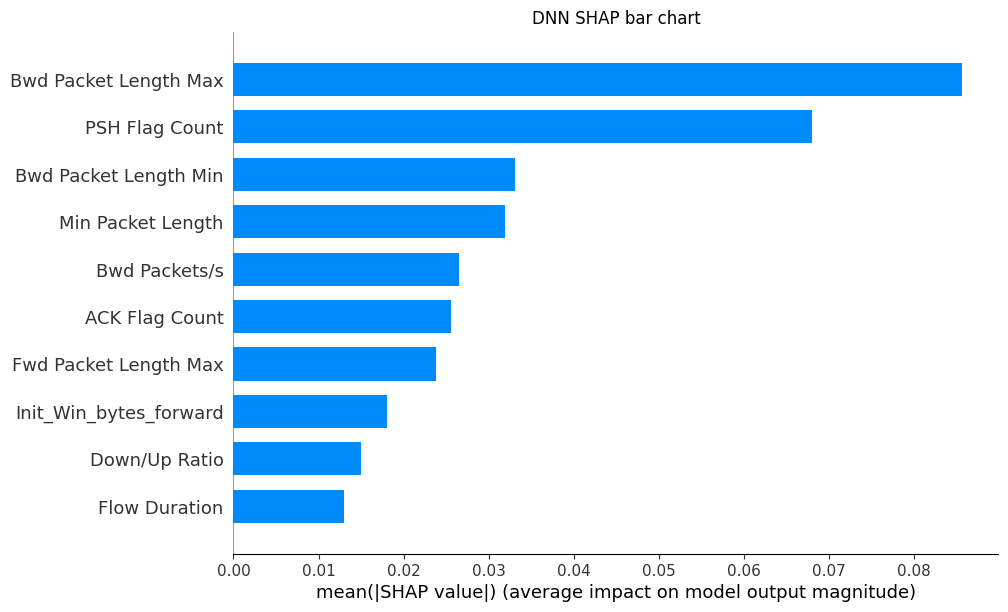


===== DNN SHAP beeswarm plot =====


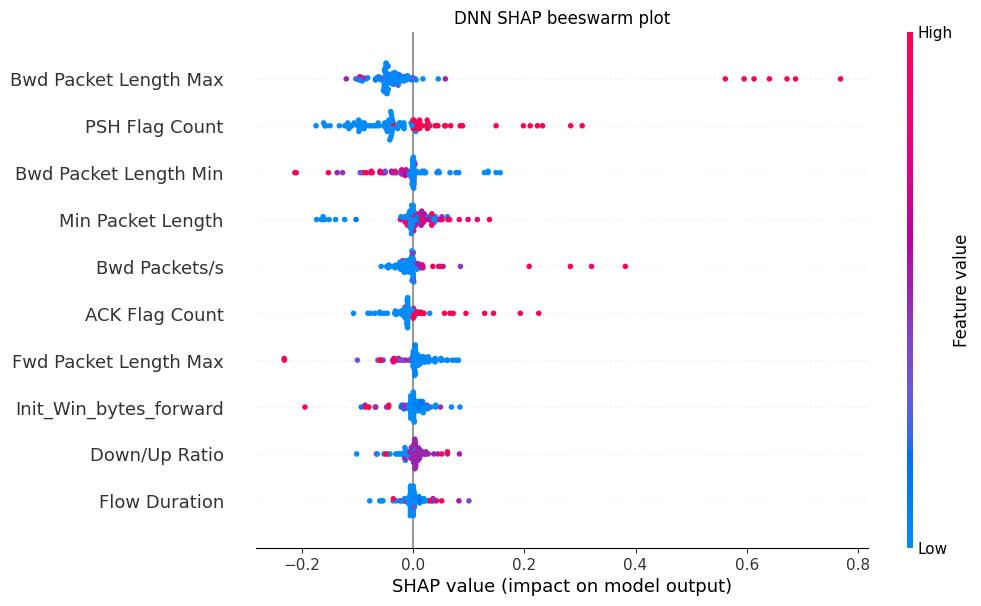

In [68]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# =========================
# SHAP SETTINGS
# =========================

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SHAP_BACKGROUND_SIZE = 100
SHAP_SAMPLE_SIZE = 100
# 100 vs 50 #for testing
# 100 vs 20 #for testing

background = shap.sample(X_train_s, SHAP_BACKGROUND_SIZE, random_state=42)
test_sample = X_test_s.iloc[:SHAP_SAMPLE_SIZE]


# =========================
# HELPER FUNCTIONS
# =========================

def to_df(X):
    return pd.DataFrame(X, columns=feature_names)

def attack_probability(model, X):
    return model.predict_proba(to_df(X))[:, 1]

def plot_shap(model_name, shap_values, X_sample):
    
    print(f"\n===== {model_name} SHAP bar chart =====")
    
    shap.summary_plot(
        shap_values,
        X_sample,
        plot_type="bar",
        max_display=10,
        show=False,
        plot_size=(12, 6)
    )
    
    plt.title(f"{model_name} SHAP bar chart")
    plt.subplots_adjust(left=0.35)
    plt.show()

    print(f"\n===== {model_name} SHAP beeswarm plot =====")
    
    shap.summary_plot(
        shap_values,
        X_sample,
        max_display=10,
        show=False,
        plot_size=(12, 6)
    )
    
    plt.title(f"{model_name} SHAP beeswarm plot")
    plt.subplots_adjust(left=0.35)
    plt.show()


# =========================
# XGBOOST SHAP
# =========================

xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap_values = xgb_explainer.shap_values(test_sample)

plot_shap("XGBoost", xgb_shap_values, test_sample)


# =========================
# SVM SHAP
# =========================

svm_explainer = shap.Explainer(
    lambda X: attack_probability(svm, X),
    background,
    algorithm="permutation"
)

svm_shap_values = svm_explainer(
    test_sample,
    max_evals=2 * len(feature_names) + 1
)

plot_shap("SVM", svm_shap_values.values, test_sample)


# =========================
# DNN SHAP
# =========================

dnn_explainer = shap.Explainer(
    lambda X: attack_probability(dnn, X),
    background,
    algorithm="permutation"
)

dnn_shap_values = dnn_explainer(
    test_sample,
    max_evals=2 * len(feature_names) + 1
)

plot_shap("DNN", dnn_shap_values.values, test_sample)

## LIME


------  LIME — XGBoost -------


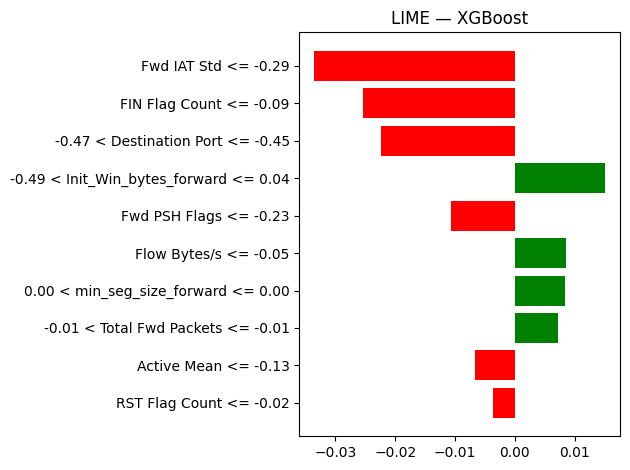


------  LIME — SVM -------


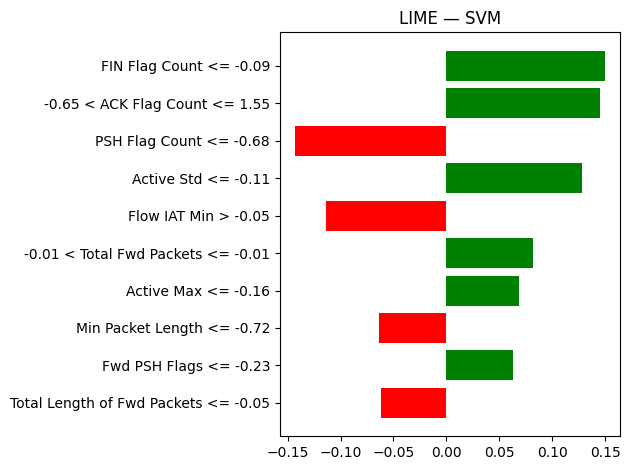


------  LIME — DNN -------


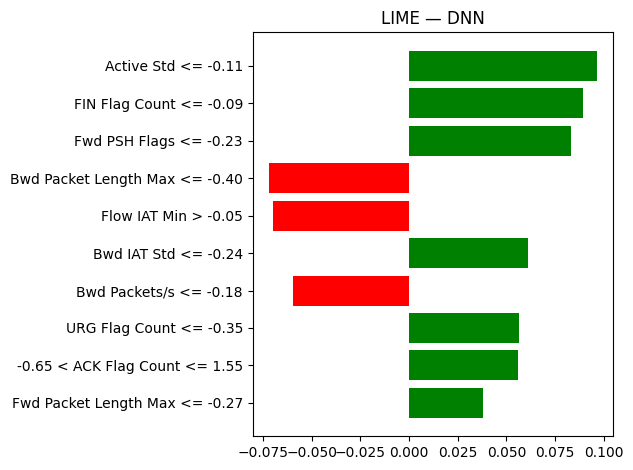

In [69]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train_s.values,
    feature_names=feature_names,
    class_names=["Benign", "Attack"],
    mode="classification",
    discretize_continuous=True
)

# one sample explanation per model — sanity check
i = 0

for name, model in [("XGBoost", xgb), ("SVM", svm), ("DNN", dnn)]:
    exp = lime_explainer.explain_instance(
        data_row=X_test_s.iloc[i].values,
        predict_fn=lambda X, model=model: model.predict_proba(pd.DataFrame(X, columns=feature_names)),
        num_features=10
    )

    print(f"\n{'------'}  LIME — {name} {'-------'}")
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME — {name}")
    plt.tight_layout()
    plt.show()

# Evaluating the XAI

## Jaccard and Spearman

In [70]:
import numpy as np
import pandas as pd
import shap
import warnings
from scipy.stats import spearmanr
from scipy.linalg import LinAlgWarning
from lime.lime_tabular import LimeTabularExplainer

# remove warnings for cleaner output

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=LinAlgWarning)

# setup

# real ideal values for a thorough experiment:
N_SAMPLES = 100      # or 200 if runtime is acceptable
N_PERTURBS = 20      # or 30
NOISE_LEVELS = [0.01, 0.05, 0.10, 0.20]
TOP_K = 5

# test values for faster runtime during development:
# N_SAMPLES = 30
# N_PERTURBS = 10
# NOISE_LEVELS = [0.01, 0.05, 0.10, 0.20]
# TOP_K = 5


RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

models = {
    "XGBoost": xgb,
    "SVM": svm,
    "DNN": dnn
}

# ideal real value
background = shap.sample(X_train_s, 100, random_state=RANDOM_STATE)
# test value
#background = shap.sample(X_train_s, 25, random_state=RANDOM_STATE)

feature_stds = X_train_s.std().values

sample_idx = np.random.choice(len(X_test_s), N_SAMPLES, replace=False)
X_samples = X_test_s.iloc[sample_idx].reset_index(drop=True)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_s.values,
    feature_names=feature_names,
    class_names=["Benign", "Attack"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

# funcs needed

def to_df(X):
    return pd.DataFrame(X, columns=feature_names)

def predict_one(model, x):
    return model.predict(to_df([x]))[0]

def predict_proba_df(model, X):
    return model.predict_proba(to_df(X))

def attack_proba(model, X):
    return predict_proba_df(model, X)[:, 1]

def make_shap_explainer(model):
    return shap.Explainer(
        lambda X: attack_proba(model, X),
        background,
        algorithm="permutation"
    )

def shap_values_one(explainer, x):
    sv = explainer(
        to_df([x]),
        max_evals=2 * len(feature_names) + 1
    )
    return np.array(sv.values).flatten()

def lime_values_one(model, x):
    exp = lime_explainer.explain_instance(
        data_row=x,
        predict_fn=lambda X: predict_proba_df(model, X),
        num_features=TOP_K
    )

    values = np.zeros(len(feature_names))

    for feat_desc, weight in exp.as_list():
        for i, name in enumerate(feature_names):
            if name in feat_desc:
                values[i] = weight
                break

    return values

def top_k(values):
    return set(np.argsort(np.abs(values))[-TOP_K:])

def jaccard(a, b):
    if len(a | b) == 0:
        return 1.0
    return len(a & b) / len(a | b)

def spearman(a, b):
    score, _ = spearmanr(a, b)
    if np.isnan(score):
        return 0.0
    return score

def perturb(x, noise_level):
    noise = np.random.normal(
        loc=0,
        scale=noise_level * feature_stds,
        size=x.shape
    )
    return x + noise

# xai stability experiment — for each model, for each sample, for each noise level, for each perturbation

results_rows = []
skipped_rows = []

for model_name, model in models.items():
    print(f"XAI stability evaluation started for {model_name}")

    shap_explainer = make_shap_explainer(model)

    for noise_level in NOISE_LEVELS:
        print(f"  {model_name}: noise level {noise_level} started")

        for i in range(N_SAMPLES):
            x_orig = X_samples.iloc[i].values
            orig_pred = predict_one(model, x_orig)

            orig_shap = shap_values_one(shap_explainer, x_orig)
            orig_lime = lime_values_one(model, x_orig)

            orig_shap_top = top_k(orig_shap)
            orig_lime_top = top_k(orig_lime)

            for p in range(N_PERTURBS):
                x_pert = perturb(x_orig, noise_level)
                pert_pred = predict_one(model, x_pert)

                if pert_pred != orig_pred:
                    skipped_rows.append({
                        "model": model_name,
                        "noise_level": noise_level,
                        "sample": i,
                        "perturbation": p,
                        "original_prediction": orig_pred,
                        "perturbed_prediction": pert_pred
                    })
                    continue

                pert_shap = shap_values_one(shap_explainer, x_pert)
                pert_lime = lime_values_one(model, x_pert)

                results_rows.append({
                    "model": model_name,
                    "noise_level": noise_level,
                    "sample": i,
                    "perturbation": p,

                    "shap_jaccard": jaccard(orig_shap_top, top_k(pert_shap)),
                    "lime_jaccard": jaccard(orig_lime_top, top_k(pert_lime)),

                    "shap_spearman": spearman(orig_shap, pert_shap),
                    "lime_spearman": spearman(orig_lime, pert_lime),

                    "original_prediction": orig_pred,
                    "perturbed_prediction": pert_pred
                })

        # print(f"  {model_name}: noise level {noise_level} finished")

    # print(f"XAI stability evaluation finished for {model_name}")

# ---------------- CREATE DATAFRAMES ----------------

results_df = pd.DataFrame(results_rows)
skipped_df = pd.DataFrame(skipped_rows)

# Optional compatibility names, in case later blocks expect these:
jaccard_df = results_df[
    ["model", "noise_level", "sample", "perturbation", "shap_jaccard", "lime_jaccard"]
].copy()

spearman_df = results_df[
    ["model", "noise_level", "sample", "perturbation", "shap_spearman", "lime_spearman"]
].copy()

jaccard_skipped_df = skipped_df.copy()
spearman_skipped_df = skipped_df.copy()

# print("XAI stability experiment complete")

XAI stability evaluation started for XGBoost
  XGBoost: noise level 0.01 started
  XGBoost: noise level 0.05 started
  XGBoost: noise level 0.1 started
  XGBoost: noise level 0.2 started
XAI stability evaluation finished for XGBoost
XAI stability evaluation started for SVM
  SVM: noise level 0.01 started
  SVM: noise level 0.05 started
  SVM: noise level 0.1 started
  SVM: noise level 0.2 started
XAI stability evaluation finished for SVM
XAI stability evaluation started for DNN
  DNN: noise level 0.01 started
  DNN: noise level 0.05 started
  DNN: noise level 0.1 started
  DNN: noise level 0.2 started
XAI stability evaluation finished for DNN


# Results

### Output Results Text: 
Text & export to csv

In [71]:
import pandas as pd

# summary tables for Jaccard and Spearman, grouped by model and noise level, showing mean, std, and count of perturbations

jaccard_summary = (
    jaccard_df
    .groupby(["model", "noise_level"])[["shap_jaccard", "lime_jaccard"]]
    .agg(["mean", "std", "count"])
    .reset_index()
)

spearman_summary = (
    spearman_df
    .groupby(["model", "noise_level"])[["shap_spearman", "lime_spearman"]]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("Jaccard Summary")
display(jaccard_summary)

print("Spearman Summary")
display(spearman_summary)

# which perturbations were skipped due to prediction changes, grouped by model and noise level

print("Skipped Jaccard perturbations due to prediction changes:")

if len(jaccard_skipped_df) > 0:
    display(
        jaccard_skipped_df
        .groupby(["model", "noise_level"])
        .size()
        .reset_index(name="skipped_count")
    )
else:
    print("No Jaccard perturbations were skipped.")

print("Skipped Spearman perturbations due to prediction changes:")

if len(spearman_skipped_df) > 0:
    display(
        spearman_skipped_df
        .groupby(["model", "noise_level"])
        .size()
        .reset_index(name="skipped_count")
    )
else:
    print("No Spearman perturbations were skipped.")

# saving the results to CSV

jaccard_df.to_csv("Results/jaccard_results.csv", index=False)
spearman_df.to_csv("Results/spearman_results.csv", index=False)
jaccard_summary.to_csv("Results/jaccard_summary.csv", index=False)
spearman_summary.to_csv("Results/spearman_summary.csv", index=False)

print("Text results complete")

Jaccard Summary


model noise_level shap_jaccard                 lime_jaccard            \
                                mean       std count         mean       std   
0       DNN        0.01     0.460984  0.187671  2000     0.441290  0.182917   
1       DNN        0.05     0.463240  0.190951  1980     0.380403  0.180366   
2       DNN        0.10     0.455648  0.186249  1941     0.342672  0.169270   
3       DNN        0.20     0.400108  0.185883  1905     0.336127  0.172880   
4       SVM        0.01     0.685446  0.183766  1943     0.595624  0.218182   
5       SVM        0.05     0.617892  0.172733  1820     0.552265  0.217068   
6       SVM        0.10     0.561597  0.179207  1688     0.526708  0.212353   
7       SVM        0.20     0.457277  0.171203  1446     0.507731  0.206664   
8   XGBoost        0.01     0.355990  0.164405  1725     0.572075  0.198788   
9   XGBoost        0.05     0.322002  0.160341  1708     0.544650  0.198870   
10  XGBoost        0.10     0.305202  0.167796  1704     0.516737  0.204876   
11  XGBoost        0.20     0.296220  0.160057  1699     0.503345  0.190296   

          
   count  
0   2000  
1   1980  
2   1941  
3   1905  
4   1943  
5   1820  
6   1688  
7   1446  
8   1725  
9   1708  
10  1704  
11  1699

Spearman Summary


model noise_level shap_spearman                 lime_spearman            \
                                 mean       std count          mean       std   
0       DNN        0.01      0.582532  0.147415  2000      0.467611  0.250416   
1       DNN        0.05      0.543358  0.146882  1980      0.411056  0.262519   
2       DNN        0.10      0.514694  0.145108  1941      0.375801  0.258539   
3       DNN        0.20      0.442130  0.153981  1905      0.348604  0.269557   
4       SVM        0.01      0.869293  0.061893  1943      0.374404  0.349492   
5       SVM        0.05      0.778848  0.080351  1820      0.337293  0.337261   
6       SVM        0.10      0.702343  0.102134  1688      0.304179  0.340819   
7       SVM        0.20      0.590575  0.120106  1446      0.279473  0.337222   
8   XGBoost        0.01      0.479496  0.146165  1725      0.433419  0.367768   
9   XGBoost        0.05      0.428437  0.154222  1708      0.321555  0.383588   
10  XGBoost        0.10      0.389422  0.165627  1704      0.246193  0.395790   
11  XGBoost        0.20      0.372888  0.170209  1699      0.203091  0.404529   

          
   count  
0   2000  
1   1980  
2   1941  
3   1905  
4   1943  
5   1820  
6   1688  
7   1446  
8   1725  
9   1708  
10  1704  
11  1699

Skipped Jaccard perturbations due to prediction changes:


,model,noise_level,skipped_count
0,DNN,0.05,20
1,DNN,0.10,59
2,DNN,0.20,95
3,SVM,0.01,57
4,SVM,0.05,180
5,SVM,0.10,312
6,SVM,0.20,554
7,XGBoost,0.01,275
8,XGBoost,0.05,292
9,XGBoost,0.10,296


Skipped Spearman perturbations due to prediction changes:


,model,noise_level,skipped_count
0,DNN,0.05,20
1,DNN,0.10,59
2,DNN,0.20,95
3,SVM,0.01,57
4,SVM,0.05,180
5,SVM,0.10,312
6,SVM,0.20,554
7,XGBoost,0.01,275
8,XGBoost,0.05,292
9,XGBoost,0.10,296


Text results complete


### Output results Visual:

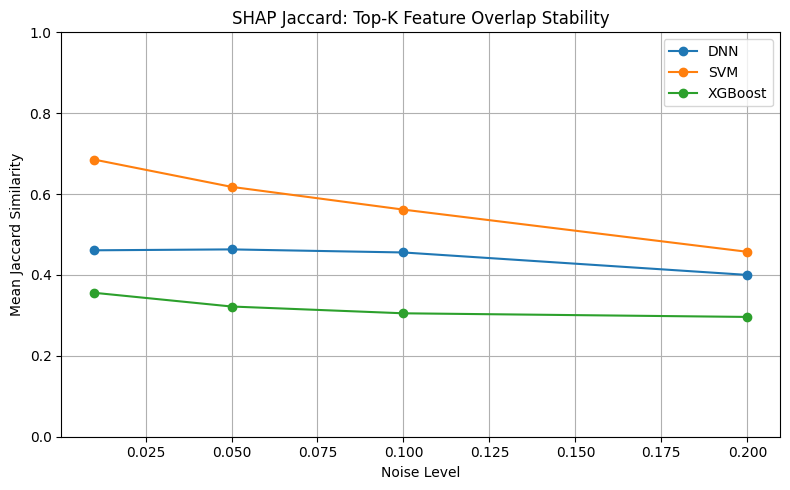

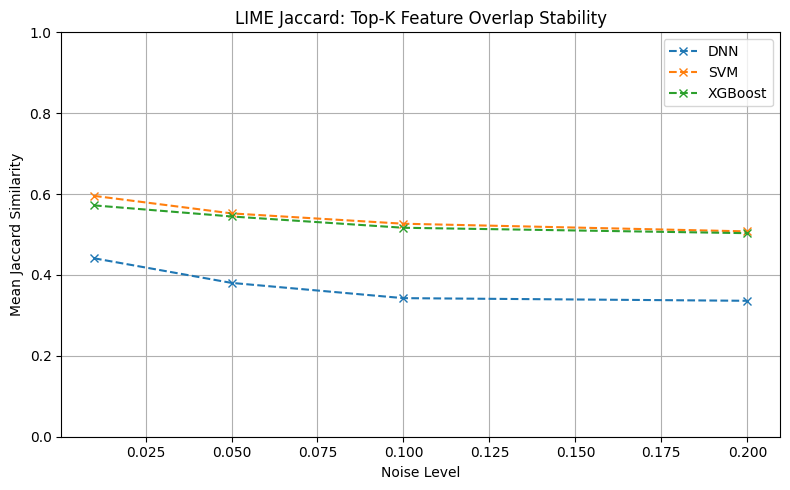

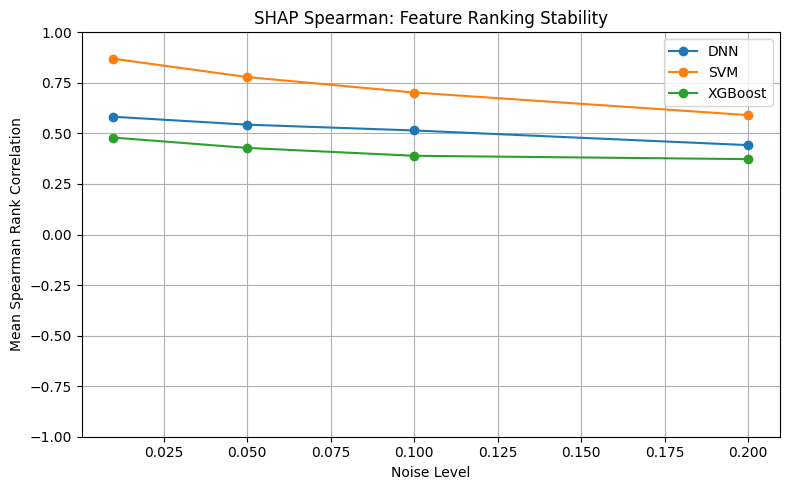

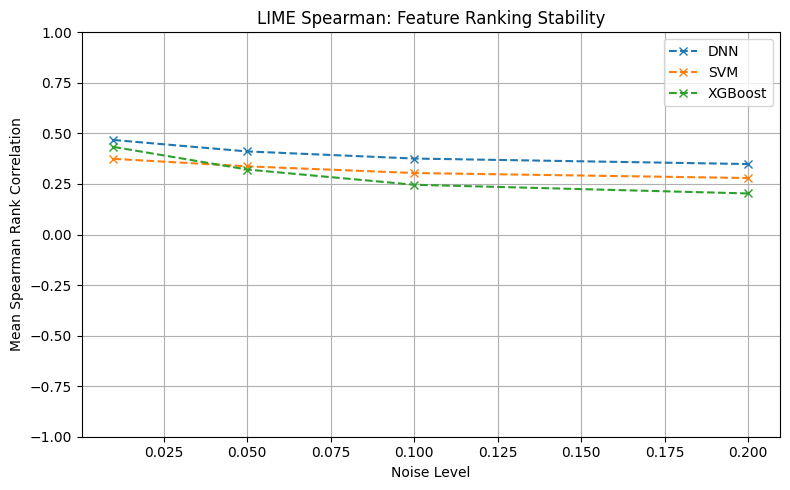

In [73]:
import matplotlib.pyplot as plt

# tables for plotting: mean Jaccard and Spearman by model and noise level

jaccard_plot_df = (
    jaccard_df
    .groupby(["model", "noise_level"])[["shap_jaccard", "lime_jaccard"]]
    .mean()
    .reset_index()
)

spearman_plot_df = (
    spearman_df
    .groupby(["model", "noise_level"])[["shap_spearman", "lime_spearman"]]
    .mean()
    .reset_index()
)

# -------------------------
# JACCARD - SHAP ONLY
# -------------------------

plt.figure(figsize=(8, 5))

for model in jaccard_plot_df["model"].unique():
    model_data = jaccard_plot_df[jaccard_plot_df["model"] == model]

    plt.plot(
        model_data["noise_level"],
        model_data["shap_jaccard"],
        marker="o",
        label=model
    )

plt.xlabel("Noise Level")
plt.ylabel("Mean Jaccard Similarity")
plt.title("SHAP Jaccard: Top-K Feature Overlap Stability")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -------------------------
# JACCARD - LIME ONLY
# -------------------------

plt.figure(figsize=(8, 5))

for model in jaccard_plot_df["model"].unique():
    model_data = jaccard_plot_df[jaccard_plot_df["model"] == model]

    plt.plot(
        model_data["noise_level"],
        model_data["lime_jaccard"],
        marker="x",
        linestyle="--",
        label=model
    )

plt.xlabel("Noise Level")
plt.ylabel("Mean Jaccard Similarity")
plt.title("LIME Jaccard: Top-K Feature Overlap Stability")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -------------------------
# SPEARMAN - SHAP ONLY
# -------------------------

plt.figure(figsize=(8, 5))

for model in spearman_plot_df["model"].unique():
    model_data = spearman_plot_df[spearman_plot_df["model"] == model]

    plt.plot(
        model_data["noise_level"],
        model_data["shap_spearman"],
        marker="o",
        label=model
    )

plt.xlabel("Noise Level")
plt.ylabel("Mean Spearman Rank Correlation")
plt.title("SHAP Spearman: Feature Ranking Stability")
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# -------------------------
# SPEARMAN - LIME ONLY
# -------------------------

plt.figure(figsize=(8, 5))

for model in spearman_plot_df["model"].unique():
    model_data = spearman_plot_df[spearman_plot_df["model"] == model]

    plt.plot(
        model_data["noise_level"],
        model_data["lime_spearman"],
        marker="x",
        linestyle="--",
        label=model
    )

plt.xlabel("Noise Level")
plt.ylabel("Mean Spearman Rank Correlation")
plt.title("LIME Spearman: Feature Ranking Stability")
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

